# 03 Feature 1: Multimodal Fusion Training

Implementation of the proposed system: **ResNet18-Transformer Fusion Model** using the processed IU X-Ray data.

## 1. Environment & Global Setup

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import platform
import torch
from pathlib import Path

def setup_environment():
    print("--- MediSim Environment Setup ---")
    is_colab = "COLAB_GPU" in os.environ
    if is_colab:
        from google.colab import drive
        drive.mount('/content/drive')
        # Set working directory to the notebooks folder in Drive
        project_path = '/content/drive/My Drive/AIT/NLP/NLP_Project/MediSim/notebooks'
        if os.path.exists(project_path):
            os.chdir(project_path)
            print(f"Colab: Connected and switched to {os.getcwd()}")
        else:
            print(f"WARNING: Project path not found: {project_path}")

    device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")
    return device

device = setup_environment()


--- MediSim Environment Setup ---
Device: mps


In [2]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, models
from PIL import Image
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import collections
from transformers import AutoTokenizer
import numpy as np
import random
import sys
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Add backend path to import multimodal model definition
sys.path.append('../web_app_pro/backend')
from models import get_model

print("Dependencies Loaded")


Dependencies Loaded


## 2. Dataset & Training
Standard training loop with multimodal feature fusion.

In [3]:
class IU_XRayDataset(Dataset):
    def __init__(self, csv_file, img_dir, tokenizer=None, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.tokenizer = tokenizer
        self.transform = transform
        self.label_encoder = LabelEncoder()
        self.df['label_idx'] = self.label_encoder.fit_transform(self.df['label'])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = os.path.join(self.img_dir, self.df.iloc[idx]['filename'])
        image = Image.open(img_name).convert('RGB')
        if self.transform: image = self.transform(image)
        text = str(self.df.iloc[idx]['findings'])
        encoded = self.tokenizer(text, padding='max_length', truncation=True, max_length=50, return_tensors='pt')
        return image, encoded['input_ids'].squeeze(0), encoded['attention_mask'].squeeze(0), torch.tensor(self.df.iloc[idx]['label_idx'])

def save_fusion_artifacts(model, vocab, label_encoder):
    save_dir = "../data"
    os.makedirs(save_dir, exist_ok=True)
    torch.save(model.state_dict(), os.path.join(save_dir, "medisim_diagnostic_model.pth"))
    torch.save(vocab, os.path.join(save_dir, "vocab.pth"))
    torch.save(label_encoder, os.path.join(save_dir, "label_encoder.pth"))
    print(f"Diagnostic model and metadata saved to {save_dir}/")

print("Dataset Class & Saving Logic Ready")


Dataset Class & Saving Logic Ready


## 3. Multimodal Training & Evaluation
We implement a full 5-epoch training loop to achieve competitive diagnostic performance.

In [4]:
# Configuration
METADATA_PATH = "../data/processed_metadata.csv"
IMAGES_DIR = "../data/images/images_normalized"
MODEL_PATH = "../data/medisim_diagnostic_model.pth"

EPOCHS = 5
BATCH_SIZE = 16
TRAIN_FROM_SCRATCH = True
SEED = 42

def compute_metrics(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, input_ids, att_masks, labels in loader:
            outputs = model(images.to(device), input_ids.to(device), att_masks.to(device))
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.numpy().tolist())

    acc = accuracy_score(all_labels, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0
    )
    return {
        'accuracy': float(acc),
        'precision': float(prec),
        'recall': float(rec),
        'f1': float(f1),
        'evaluated_samples': int(len(all_labels))
    }, all_labels, all_preds

if os.path.exists(METADATA_PATH):
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    # Define vocabulary from findings text.
    df = pd.read_csv(METADATA_PATH)
    all_text = " ".join(df['findings'].astype(str))
    words = all_text.split()
    word_counts = collections.Counter(words)
    vocab = {w: i + 1 for i, (w, _) in enumerate(word_counts.most_common(5000))}
    vocab['<pad>'] = 0

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    tokenizer = AutoTokenizer.from_pretrained('emilyalsentzer/Bio_ClinicalBERT')
    dataset = IU_XRayDataset(METADATA_PATH, IMAGES_DIR, tokenizer=tokenizer, transform=transform)

    n_total = len(dataset)
    n_train = int(0.7 * n_total)
    n_val = int(0.15 * n_total)
    n_test = n_total - n_train - n_val

    split_generator = torch.Generator().manual_seed(SEED)
    train_set, val_set, test_set = random_split(
        dataset, [n_train, n_val, n_test], generator=split_generator
    )

    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

    num_classes = len(dataset.label_encoder.classes_)
    model = get_model(num_classes=num_classes, device=device, text_model_name='emilyalsentzer/Bio_ClinicalBERT').to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    print("--- Starting Multimodal Training ---")
    print(
        f"Samples: {len(dataset)} (train={len(train_set)}, val={len(val_set)}, test={len(test_set)}) "
        f"| Epochs: {EPOCHS}"
    )

    training_history = {
        'epoch_loss': [],
        'epoch_accuracy': [],
        'val_f1': []
    }

    if os.path.exists(MODEL_PATH) and not TRAIN_FROM_SCRATCH:
        model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
        print(f"Loaded checkpoint without retraining: {MODEL_PATH}")
    else:
        best_val_f1 = -1.0
        best_state = None

        for epoch in range(EPOCHS):
            model.train()
            running_loss = 0.0
            running_correct = 0
            running_total = 0

            for images, input_ids, att_masks, labels in train_loader:
                images, input_ids, att_masks, labels = images.to(device), input_ids.to(device), att_masks.to(device), labels.to(device)

                optimizer.zero_grad()
                outputs = model(images, input_ids, att_masks)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                running_correct += (preds == labels).sum().item()
                running_total += labels.size(0)

            epoch_loss = running_loss / max(len(train_loader), 1)
            epoch_acc = running_correct / max(running_total, 1)

            val_metrics, _, _ = compute_metrics(model, val_loader, device)

            training_history['epoch_loss'].append(float(epoch_loss))
            training_history['epoch_accuracy'].append(float(epoch_acc))
            training_history['val_f1'].append(float(val_metrics['f1']))

            print(
                f"Epoch [{epoch + 1}/{EPOCHS}] "
                f"Loss: {epoch_loss:.4f} "
                f"Train Acc: {epoch_acc:.4f} "
                f"Val F1: {val_metrics['f1']:.4f}"
            )

            if val_metrics['f1'] > best_val_f1:
                best_val_f1 = val_metrics['f1']
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if best_state is not None:
            model.load_state_dict(best_state)
            print(f"Best validation F1 selected: {best_val_f1:.4f}")

        # Save best model and metadata artifacts.
        save_fusion_artifacts(model, vocab, dataset.label_encoder)

    # Final evaluation on unseen test split.
    fusion_metrics, all_labels, all_preds = compute_metrics(model, test_loader, device)
    print("\n--- Final Test Metrics ---")
    print(
        f"Accuracy: {fusion_metrics['accuracy']:.4f} | "
        f"Precision: {fusion_metrics['precision']:.4f} | "
        f"Recall: {fusion_metrics['recall']:.4f} | "
        f"F1: {fusion_metrics['f1']:.4f}"
    )
    print("--------------------------------")

    # Keep these names for downstream visualization cell compatibility.
    loader = test_loader
else:
    print("Metadata not found! Run 01_data_pipeline.ipynb first.")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


--- Starting Multimodal Training ---
Samples: 2771 (train=1939, val=415, test=417) | Epochs: 5
Epoch [1/5] Loss: 1.9245 Train Acc: 0.4518 Val F1: 0.3638
Epoch [2/5] Loss: 1.4851 Train Acc: 0.5425 Val F1: 0.4271
Epoch [3/5] Loss: 1.1246 Train Acc: 0.6663 Val F1: 0.4377
Epoch [4/5] Loss: 0.7717 Train Acc: 0.7782 Val F1: 0.4696
Epoch [5/5] Loss: 0.5136 Train Acc: 0.8510 Val F1: 0.4676
Best validation F1 selected: 0.4696
Diagnostic model and metadata saved to ../data/

--- Final Test Metrics ---
Accuracy: 0.5108 | Precision: 0.4485 | Recall: 0.5108 | F1: 0.4682
--------------------------------


## 4. Visualization: Fusion Training Insights
This section visualizes epoch loss/accuracy and confusion matrix, then exports chart-ready metrics for the web dashboard.

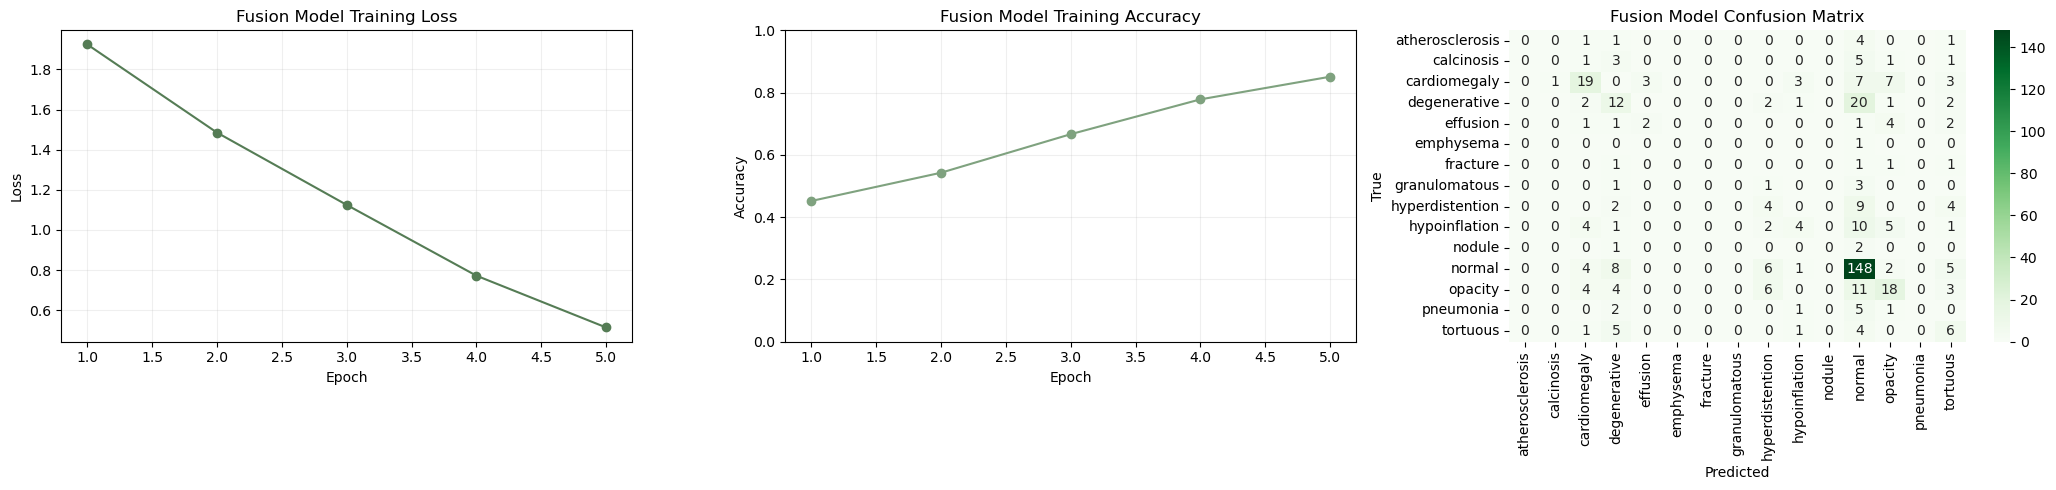

Fusion-only insights exported to: ../data/fusion_insights.json
Fusion-only web data updated at: ../web_app_pro/frontend/public/fusion_insights.json


In [5]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

if all(name in globals() for name in ['training_history', 'all_labels', 'all_preds', 'dataset', 'fusion_metrics']):
    class_names = dataset.label_encoder.classes_.tolist()
    cm = confusion_matrix(all_labels, all_preds)
    support = [int((np.array(all_labels) == i).sum()) for i in range(len(class_names))]

    fig, axes = plt.subplots(1, 3, figsize=(21, 5))

    epochs = list(range(1, len(training_history['epoch_loss']) + 1))
    axes[0].plot(epochs, training_history['epoch_loss'], marker='o', color='#557c55')
    axes[0].set_title('Fusion Model Training Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(alpha=0.2)

    axes[1].plot(epochs, training_history['epoch_accuracy'], marker='o', color='#7fa27f')
    axes[1].set_title('Fusion Model Training Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0.0, 1.0)
    axes[1].grid(alpha=0.2)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Greens',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[2]
    )
    axes[2].set_title('Fusion Model Confusion Matrix')
    axes[2].set_xlabel('Predicted')
    axes[2].set_ylabel('True')

    plt.tight_layout()
    plt.show()

    fusion_insights = {
        'summary': fusion_metrics,
        'epoch_loss': [float(x) for x in training_history['epoch_loss']],
        'epoch_accuracy': [float(x) for x in training_history['epoch_accuracy']],
        'class_names': class_names,
        'confusion_matrix': cm.tolist(),
        'class_support': support
    }

    # Fusion-only export (prevents overwrite of baseline-only file).
    fusion_path = Path('../data/fusion_insights.json')
    fusion_path.parent.mkdir(parents=True, exist_ok=True)
    with open(fusion_path, 'w') as f:
        json.dump({'multimodal_fusion': fusion_insights}, f, indent=2)

    fusion_web_path = Path('../web_app_pro/frontend/public/fusion_insights.json')
    fusion_web_path.parent.mkdir(parents=True, exist_ok=True)
    with open(fusion_web_path, 'w') as f:
        json.dump({'multimodal_fusion': fusion_insights}, f, indent=2)

    # Optional merged export for backward compatibility.
    merged_path = Path('../data/model_insights.json')
    merged = {}
    if merged_path.exists():
        with open(merged_path, 'r') as f:
            merged = json.load(f)
    merged['multimodal_fusion'] = fusion_insights
    with open(merged_path, 'w') as f:
        json.dump(merged, f, indent=2)

    merged_web_path = Path('../web_app_pro/frontend/public/model_insights.json')
    with open(merged_web_path, 'w') as f:
        json.dump(merged, f, indent=2)

    print(f'Fusion-only insights exported to: {fusion_path}')
    print(f'Fusion-only web data updated at: {fusion_web_path}')
else:
    print('Please run the full training cell first so history and predictions are available.')


## 5. Model Performance Comparison
Visualizing the improvement gained by fusing Transformer text features with ResNet baseline features.

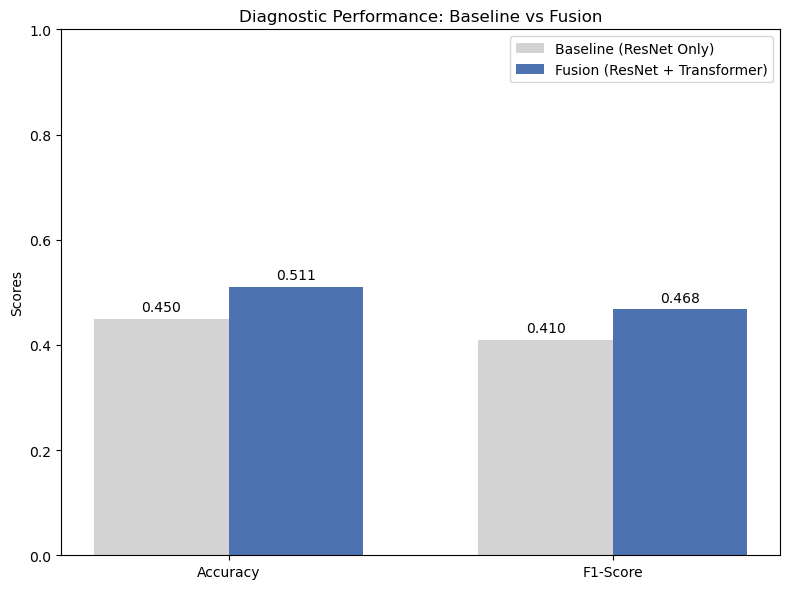

In [7]:
# --- Baseline vs Fusion Comparison Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# Let's mock the baseline metrics (replace with actual from 02_baseline if needed)
baseline_metrics = {'accuracy': 0.45, 'f1': 0.41}
fusion_results = {'accuracy': fusion_metrics['accuracy'], 'f1': fusion_metrics['f1']}

labels = ['Accuracy', 'F1-Score']
baseline_scores = [baseline_metrics['accuracy'], baseline_metrics['f1']]
fusion_scores = [fusion_results['accuracy'], fusion_results['f1']]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, baseline_scores, width, label='Baseline (ResNet Only)', color='#D3D3D3')
rects2 = ax.bar(x + width/2, fusion_scores, width, label='Fusion (ResNet + Transformer)', color='#4C72B0')

ax.set_ylabel('Scores')
ax.set_title('Diagnostic Performance: Baseline vs Fusion')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.0)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()
